In [2]:
#DATA LOADING AND PREPROCESSING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, silhouette_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.cluster import KMeans
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


# Load data
data = pd.read_excel("Copy of customer_purchase_data.xlsx")



In [214]:
sns.set_style("whitegrid")
C1 = "#003049"     # primary
C2 = "#a3cef1"     # secondary / contrast
C3 = "#ff9b85"     # highlight / box annotation

In [215]:
print("Dataset Shape:", data.shape)
display(data.head())
display(data.info())
display(data.describe().T)
print(data.isnull().sum())


Dataset Shape: (1500, 9)


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


None

,count,mean,std,min,25%,50%,75%,max
Age,1500.0,44.298667,15.537259,18.000000,31.000000,45.000000,57.000000,70.000000
Gender,1500.0,0.504667,0.500145,0.000000,0.000000,1.000000,1.000000,1.000000
AnnualIncome,1500.0,84249.164338,37629.493078,20001.512518,53028.979155,83699.581476,117167.772858,149785.176481
NumberOfPurchases,1500.0,10.420000,5.887391,0.000000,5.000000,11.000000,15.000000,20.000000
ProductCategory,1500.0,2.012667,1.428005,0.000000,1.000000,2.000000,3.000000,4.000000
TimeSpentOnWebsite,1500.0,30.469040,16.984392,1.037023,16.156700,30.939516,44.369863,59.991105
LoyaltyProgram,1500.0,0.326667,0.469151,0.000000,0.000000,0.000000,1.000000,1.000000
DiscountsAvailed,1500.0,2.555333,1.705152,0.000000,1.000000,3.000000,4.000000,5.000000
PurchaseStatus,1500.0,0.432000,0.495520,0.000000,0.000000,0.000000,1.000000,1.000000


Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


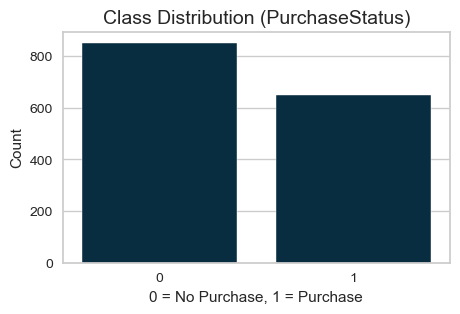

In [216]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="PurchaseStatus", color=C1)
plt.title("Class Distribution (PurchaseStatus)", fontsize=14)
plt.xlabel("0 = No Purchase, 1 = Purchase")
plt.ylabel("Count")
plt.show()

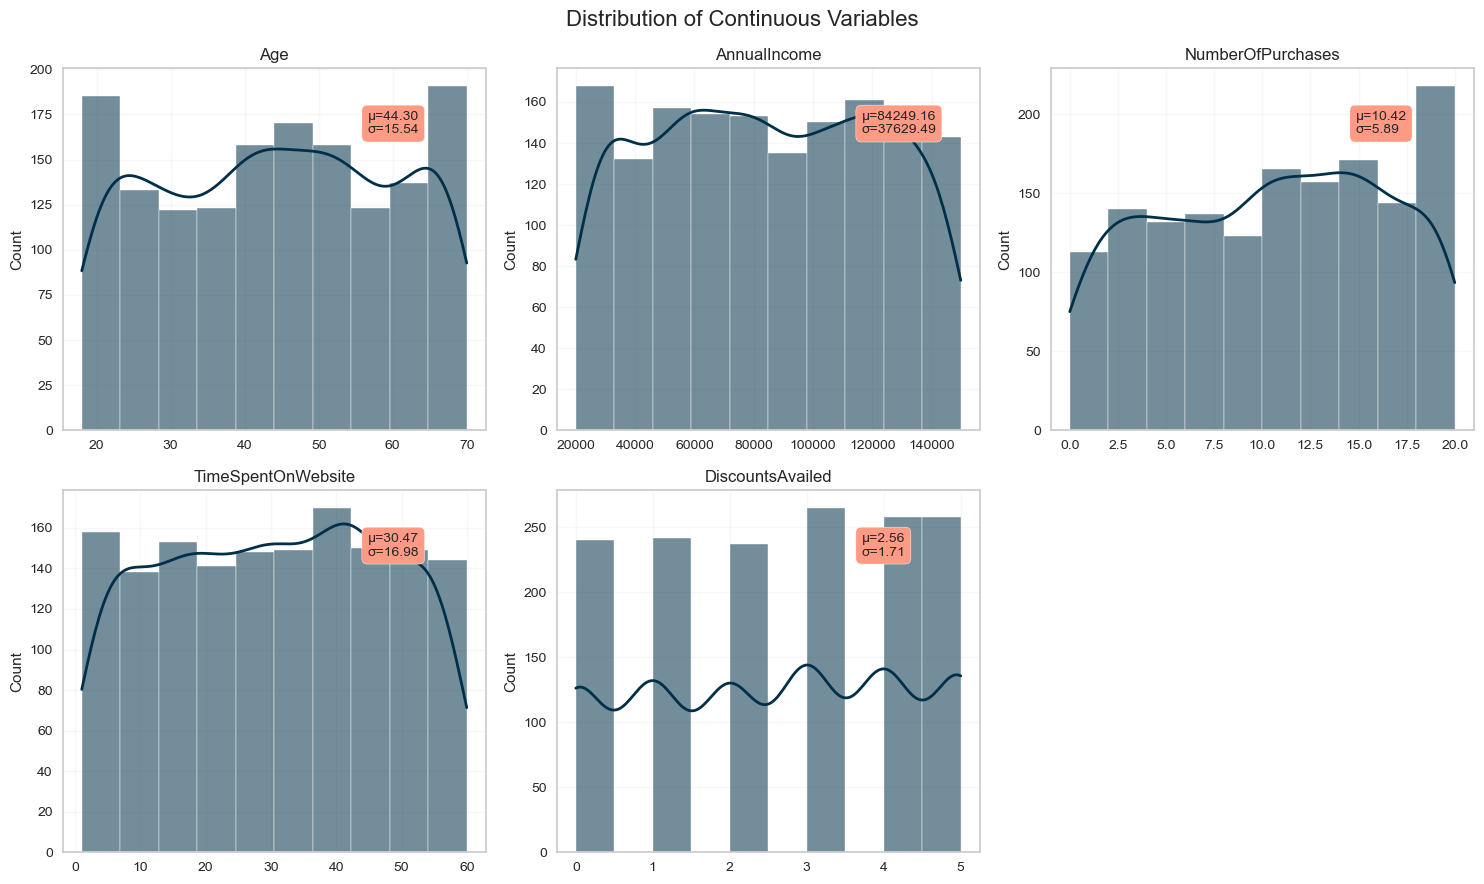

In [217]:
continuous = ["Age", "AnnualIncome", "NumberOfPurchases", "TimeSpentOnWebsite", "DiscountsAvailed"]
df_cont = data[continuous]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,9))
ax = ax.flatten()

for i, col in enumerate(df_cont.columns):
    values, bins = np.histogram(df_cont[col])
    
    sns.histplot(
        df_cont[col], 
        bins=bins, 
        kde=True, 
        ax=ax[i],
        color=C1,
        alpha=0.55,
        edgecolor="white",
        line_kws={"lw":2, "color":C2}
    )
    
    ax[i].set_title(col, fontsize=12)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("Count")
    ax[i].grid(alpha=0.15)

    text = f"μ={df_cont[col].mean():.2f}\nσ={df_cont[col].std():.2f}"
    ax[i].text(
        0.72, 0.82, text,
        transform=ax[i].transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round", pad=0.4, facecolor=C3, edgecolor="white")
    )

# Remove unused cell
for j in range(len(df_cont.columns), len(ax)):
    fig.delaxes(ax[j])

plt.suptitle("Distribution of Continuous Variables", fontsize=16)
plt.tight_layout()
plt.show()


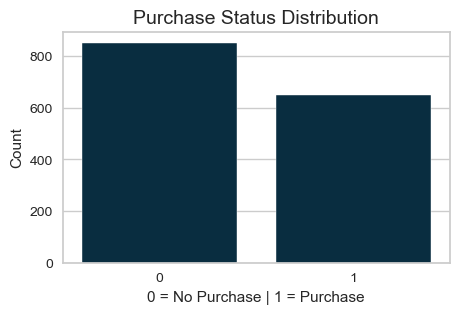

In [218]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="PurchaseStatus", color=C1)
plt.title("Purchase Status Distribution", fontsize=14)
plt.xlabel("0 = No Purchase | 1 = Purchase")
plt.ylabel("Count")
plt.show()


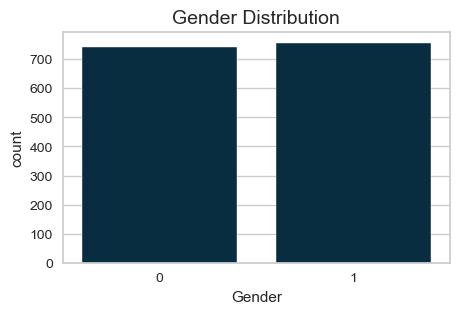

In [219]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="Gender", color=C1)
plt.title("Gender Distribution", fontsize=14)
plt.show()


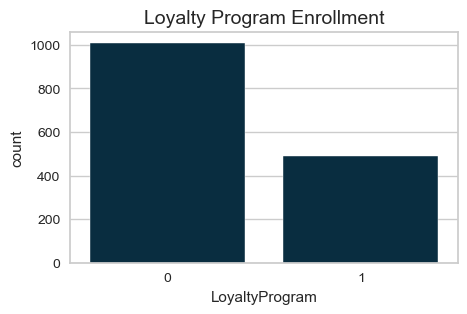

In [220]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="LoyaltyProgram", color=C1)
plt.title("Loyalty Program Enrollment", fontsize=14)
plt.show()


/var/folders/cf/pcl6gwsd1zq1yknkv7bb2ydm0000gn/T/ipykernel_6378/2767302380.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


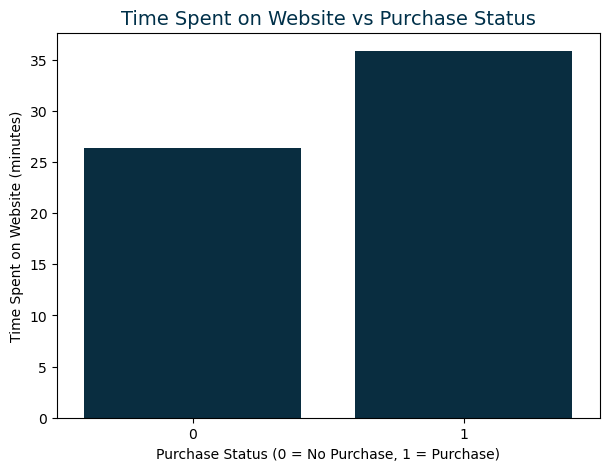

In [7]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=data,
    x="PurchaseStatus",
    y="TimeSpentOnWebsite",
    color="#003049",   # your requested colour
    ci=None           # removes error bars
)

plt.title("Time Spent on Website vs Purchase Status", fontsize=14, color="#003049")
plt.xlabel("Purchase Status (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Time Spent on Website (minutes)")
plt.show()


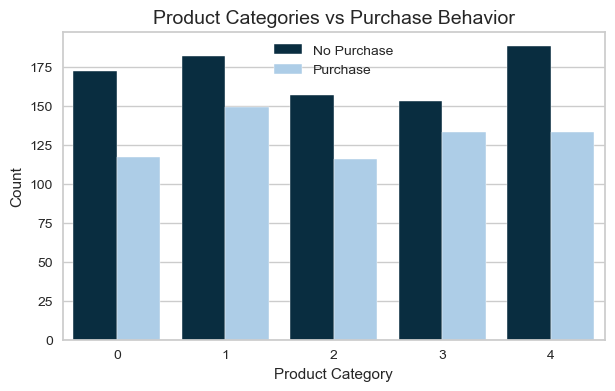

In [221]:
plt.figure(figsize=(7,4))
sns.countplot(x="ProductCategory", hue="PurchaseStatus", data=data, palette=[C1, C2])
plt.title("Product Categories vs Purchase Behavior", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.legend(["No Purchase", "Purchase"])
plt.show()


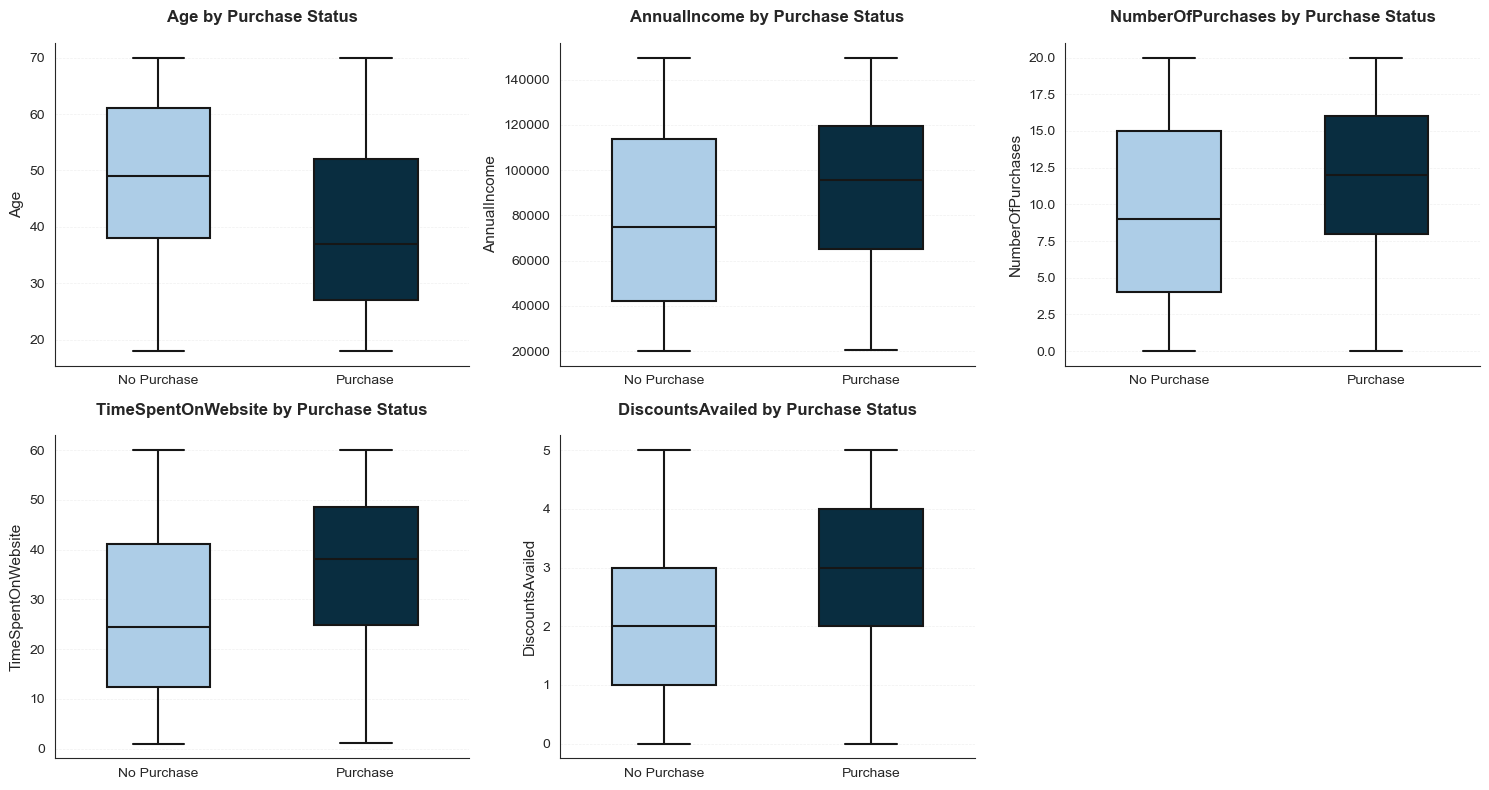

In [3]:
# Clean, aesthetic box plots
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean style
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'

# Define colors
primary = "#a3cef1"
secondary = "#003049"

# Numerical features
numerical_features = ['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'DiscountsAvailed']

# Categorical feature
categorical_feature = 'PurchaseStatus', 'Gender'

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    
    sns.boxplot(
        data=data,
        x='PurchaseStatus',
        y=feature,
        ax=ax,
        hue="PurchaseStatus",
        palette=[primary, secondary],
        width=0.5,
        linewidth=1.5,
        fliersize=3,
        legend=False
    )
    
    ax.set_title(f'{feature} by Purchase Status', fontsize=12, fontweight='600', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel(feature, fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Purchase', 'Purchase'])

    # Aesthetic cleanup
    sns.despine(ax=ax, left=False, bottom=False)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

# Remove empty plot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


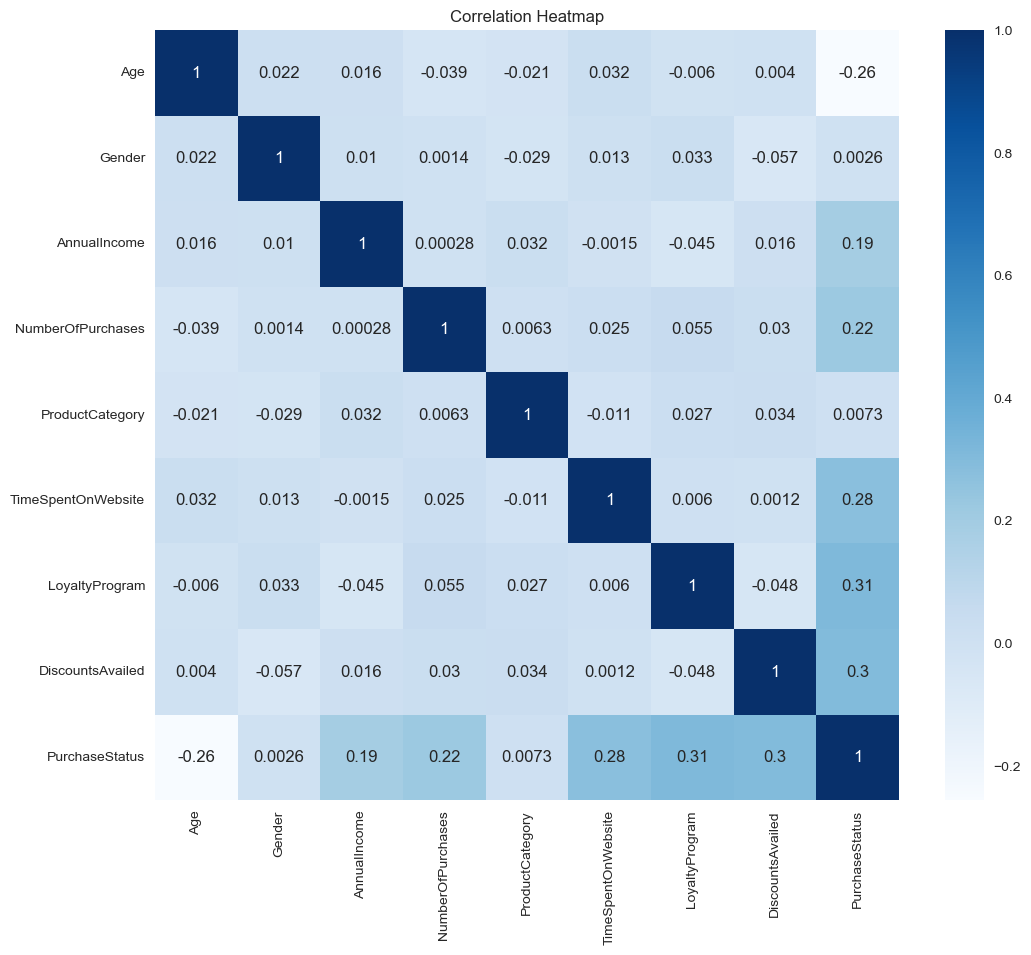

In [223]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [224]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Split data
X = data.drop("PurchaseStatus", axis=1)
y = data["PurchaseStatus"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaling — only for distance/margin-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [225]:
def eval_clf(name, model, X_test, y_test, show_cm=True):
    y_pred = model.predict(X_test)

    # Probability scores
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        prob = model.decision_function(X_test)

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, digits=4))

    # ROC / AUC
    auc = roc_auc_score(y_test, prob)
    print(f"AUC-ROC: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=PINK)
    plt.plot([0,1], [0,1], "--", color=LIGHTBLUE)
    plt.title(f"ROC: {name}", color=PINK)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    if show_cm:
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))


In [226]:
k_values = list(range(1, 31, 2))
metrics_to_test = ["minkowski", "manhattan", "cosine"]

best_knn_score = 0
best_knn_params = None
best_knn_model = None

for metric in metrics_to_test:
    if metric == "minkowski":
        params = {"metric": ["minkowski"], "n_neighbors": k_values, "p": [2]}
    else:
        params = {"metric": [metric], "n_neighbors": k_values}

    model = KNeighborsClassifier()
    grid = GridSearchCV(model, params, scoring="f1", cv=cv, n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    print(f"{metric} → best params {grid.best_params_}, F1={grid.best_score_:.4f}")

    if grid.best_score_ > best_knn_score:
        best_knn_score = grid.best_score_
        best_knn_params = grid.best_params_
        best_knn_model = grid.best_estimator_


minkowski → best params {'metric': 'minkowski', 'n_neighbors': 7, 'p': 2}, F1=0.8051
manhattan → best params {'metric': 'manhattan', 'n_neighbors': 7}, F1=0.7976
cosine → best params {'metric': 'cosine', 'n_neighbors': 5}, F1=0.8020


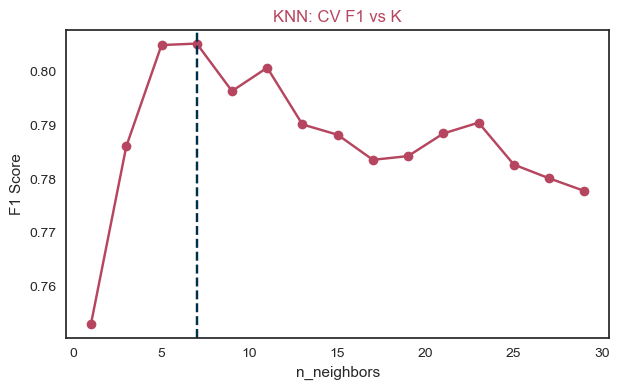

In [227]:
metric = best_knn_params["metric"]
results = next(res for m, res in knn_cv_results if m == metric)

df_scores = pd.DataFrame({
    "k": [p["n_neighbors"] for p in results["params"]],
    "score": results["mean_test_score"]
}).groupby("k").max()

plt.figure(figsize=(7,4))
plt.plot(df_scores.index, df_scores.score, marker="o", color=PINK)
plt.axvline(best_knn_params["n_neighbors"], ls="--", color=LIGHTBLUE)
plt.title("KNN: CV F1 vs K", color=PINK)
plt.xlabel("n_neighbors")
plt.ylabel("F1 Score")
plt.show()


=== KNN (best) ===
              precision    recall  f1-score   support

           0     0.8588    0.8588    0.8588       170
           1     0.8154    0.8154    0.8154       130

    accuracy                         0.8400       300
   macro avg     0.8371    0.8371    0.8371       300
weighted avg     0.8400    0.8400    0.8400       300

AUC-ROC: 0.9095


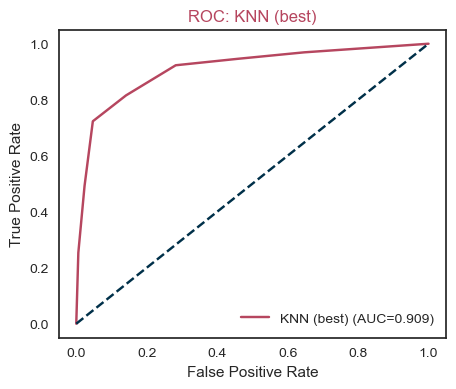

Confusion Matrix:
[[146  24]
 [ 24 106]]


In [228]:
best_knn_model.fit(X_train_scaled, y_train)
eval_clf("KNN (best)", best_knn_model, X_test_scaled, y_test)


DECISION TREE

Best: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
=== Decision Tree (best) ===
              precision    recall  f1-score   support

           0     0.9091    0.9412    0.9249       170
           1     0.9194    0.8769    0.8976       130

    accuracy                         0.9133       300
   macro avg     0.9142    0.9090    0.9112       300
weighted avg     0.9135    0.9133    0.9131       300

AUC-ROC: 0.9029


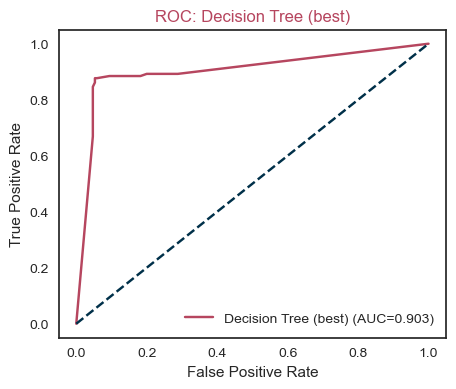

Confusion Matrix:
[[160  10]
 [ 16 114]]


In [229]:
dt = DecisionTreeClassifier(random_state=42)
params_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

grid_dt = GridSearchCV(dt, params_dt, scoring="f1", cv=cv, n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("Best:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_
eval_clf("Decision Tree (best)", best_dt, X_test, y_test)


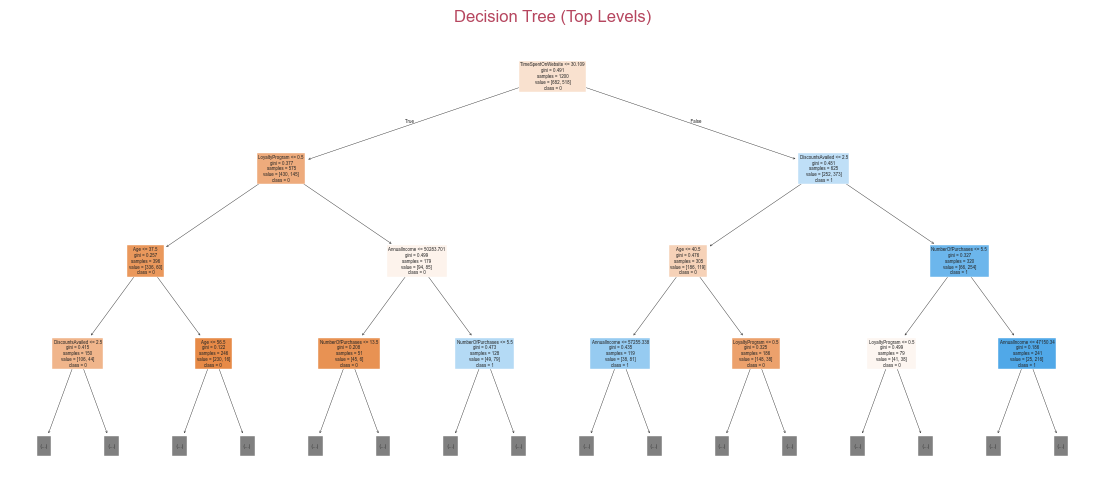

In [230]:
plt.figure(figsize=(14,6))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["0","1"],
    filled=True,
    max_depth=3
)
plt.title("Decision Tree (Top Levels)", color=PINK)
plt.show()


RANDOM FOREST

Best: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}
=== Random Forest (best) ===
              precision    recall  f1-score   support

           0     0.9314    0.9588    0.9449       170
           1     0.9440    0.9077    0.9255       130

    accuracy                         0.9367       300
   macro avg     0.9377    0.9333    0.9352       300
weighted avg     0.9369    0.9367    0.9365       300

AUC-ROC: 0.9395


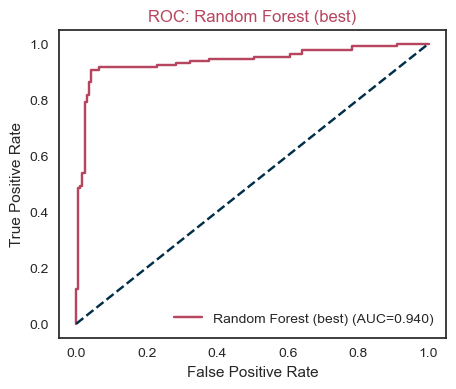

Confusion Matrix:
[[163   7]
 [ 12 118]]


In [231]:
rf = RandomForestClassifier(random_state=42)
params_rf = {
    "n_estimators": [100,200],
    "max_depth": [None,5,10],
    "max_features": ["sqrt","log2",0.5],
    "min_samples_leaf": [1,2,4]
}

grid_rf = GridSearchCV(rf, params_rf, scoring="f1", cv=cv, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
eval_clf("Random Forest (best)", best_rf, X_test, y_test)


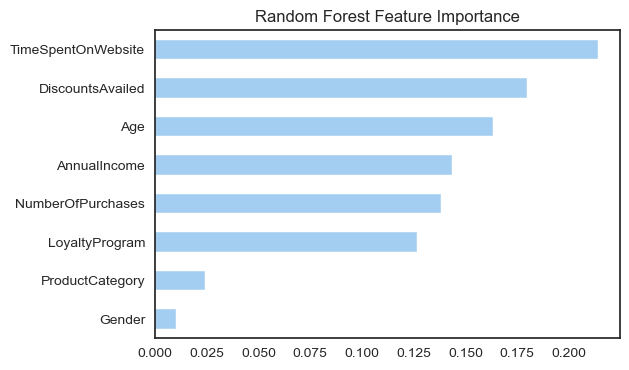

In [232]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(6,4), color=primary)
plt.title("Random Forest Feature Importance")
plt.show()


Gradient Boosting

Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
=== Gradient Boosting (best) ===
              precision    recall  f1-score   support

           0     0.9310    0.9529    0.9419       170
           1     0.9365    0.9077    0.9219       130

    accuracy                         0.9333       300
   macro avg     0.9338    0.9303    0.9319       300
weighted avg     0.9334    0.9333    0.9332       300

AUC-ROC: 0.9420


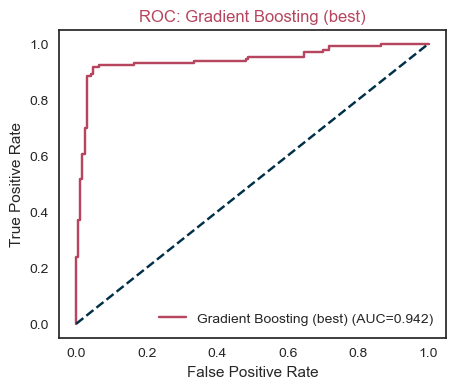

Confusion Matrix:
[[162   8]
 [ 12 118]]


In [233]:
gb = GradientBoostingClassifier(random_state=42)
params_gb = {
    "n_estimators": [100,200],
    "learning_rate": [0.01,0.05,0.1],
    "max_depth": [3,5],
    "subsample": [1,0.8]
}

grid_gb = GridSearchCV(gb, params_gb, scoring="f1", cv=cv, n_jobs=-1)
grid_gb.fit(X_train, y_train)

print("Best:", grid_gb.best_params_)
best_gb = grid_gb.best_estimator_
eval_clf("Gradient Boosting (best)", best_gb, X_test, y_test)


=== GaussianNB ===
              precision    recall  f1-score   support

           0     0.8011    0.8529    0.8262       170
           1     0.7899    0.7231    0.7550       130

    accuracy                         0.7967       300
   macro avg     0.7955    0.7880    0.7906       300
weighted avg     0.7963    0.7967    0.7954       300

AUC-ROC: 0.8680


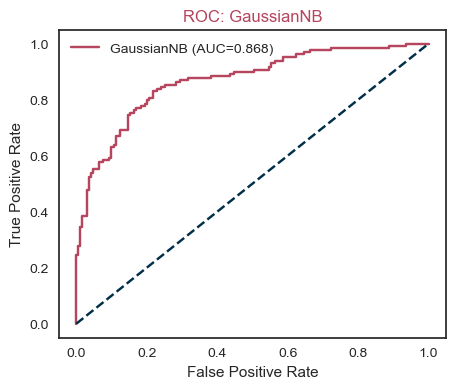

Confusion Matrix:
[[145  25]
 [ 36  94]]


TypeError: cannot unpack non-iterable NoneType object

In [234]:
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
_, _ = eval_clf("GaussianNB", gnb, X_test, y_test)

# LDA (on scaled features)
lda = LDA()
lda.fit(X_train_scaled, y_train)
_, _ = eval_clf("LDA", lda, X_test_scaled, y_test)

# QDA (on scaled features)
qda = QDA()
qda.fit(X_train_scaled, y_train)
_, _ = eval_clf("QDA", qda, X_test_scaled, y_test)


GaussianNB / LDA / QDA

=== GaussianNB ===
              precision    recall  f1-score   support

           0     0.8011    0.8529    0.8262       170
           1     0.7899    0.7231    0.7550       130

    accuracy                         0.7967       300
   macro avg     0.7955    0.7880    0.7906       300
weighted avg     0.7963    0.7967    0.7954       300

AUC-ROC: 0.8680


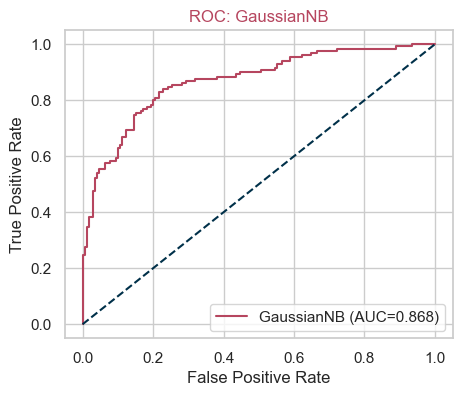

Confusion Matrix:
[[145  25]
 [ 36  94]]
=== LDA ===
              precision    recall  f1-score   support

           0     0.8324    0.8765    0.8539       170
           1     0.8264    0.7692    0.7968       130

    accuracy                         0.8300       300
   macro avg     0.8294    0.8229    0.8253       300
weighted avg     0.8298    0.8300    0.8291       300

AUC-ROC: 0.8980


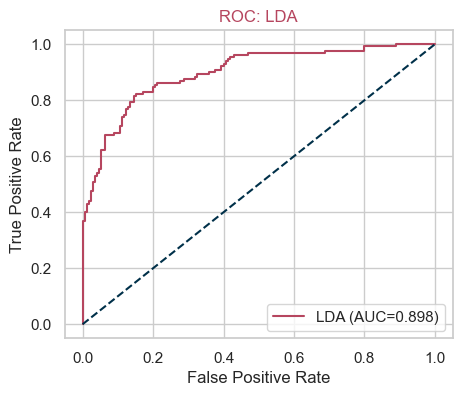

Confusion Matrix:
[[149  21]
 [ 30 100]]
=== QDA ===
              precision    recall  f1-score   support

           0     0.8371    0.8765    0.8563       170
           1     0.8279    0.7769    0.8016       130

    accuracy                         0.8333       300
   macro avg     0.8325    0.8267    0.8290       300
weighted avg     0.8331    0.8333    0.8326       300

AUC-ROC: 0.9085


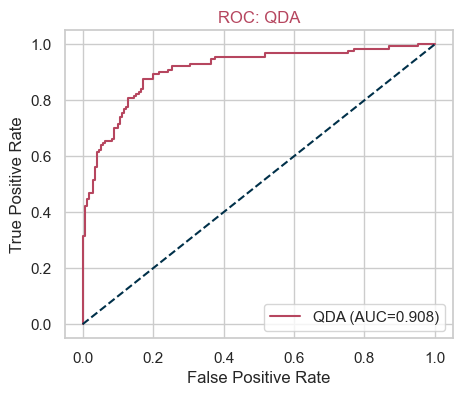

Confusion Matrix:
[[149  21]
 [ 29 101]]


In [ ]:
gnb = GaussianNB().fit(X_train, y_train)
eval_clf("GaussianNB", gnb, X_test, y_test)

lda = LDA().fit(X_train_scaled, y_train)
eval_clf("LDA", lda, X_test_scaled, y_test)

qda = QDA().fit(X_train_scaled, y_train)
eval_clf("QDA", qda, X_test_scaled, y_test)


Model Comparison Table

In [ ]:
models = {
    "KNN": best_knn_model,
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "GradientBoosting": best_gb,
    "GaussianNB": gnb,
    "LDA": lda,
    "QDA": qda
}

results = []
for name, model in models.items():

    input_test = X_test_scaled if name in ["KNN","LDA","QDA"] else X_test
    pred = model.predict(input_test)
    prob = model.predict_proba(input_test)[:,1] if hasattr(model,"predict_proba") else model.decision_function(input_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred),
        "Recall": recall_score(y_test,pred),
        "F1": f1_score(y_test,pred),
        "AUC": roc_auc_score(y_test,prob),
    })

pd.DataFrame(results).sort_values("F1",ascending=False)


,Model,Accuracy,Precision,Recall,F1,AUC
2,RandomForest,0.936667,0.944000,0.907692,0.925490,0.939502
3,GradientBoosting,0.933333,0.936508,0.907692,0.921875,0.942036
1,DecisionTree,0.913333,0.919355,0.876923,0.897638,0.902919
0,KNN,0.840000,0.815385,0.815385,0.815385,0.909457
6,QDA,0.833333,0.827869,0.776923,0.801587,0.908462
5,LDA,0.830000,0.826446,0.769231,0.796813,0.898009
4,GaussianNB,0.796667,0.789916,0.723077,0.755020,0.867964


UNSUPERVISED LEARNING

DATA PREP ND PROCESSING

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Set style
sns.set_style("whitegrid")
C1 = "#003049"  # primary
C2 = "#a3cef1"  # secondary


In [ ]:
cluster_features = [
    "Age",
    "AnnualIncome", 
    "NumberOfPurchases",
    "TimeSpentOnWebsite",
    "DiscountsAvailed"
]

X = data[cluster_features].copy()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print("DATA PREPARATION")
print(f"Features used: {cluster_features}")
print(f"Data shape: {X_scaled.shape}")
print()

DATA PREPARATION
Features used: ['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'DiscountsAvailed']
Data shape: (1500, 5)



PCA 

In [ ]:
# Use 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.3f}")
print()


Variance explained by 2 components: 0.417



ELBOW METHOD + SILHOUETTE ANALYSIS


Testing different values of k...
k=2: Inertia=2061.63, Silhouette=0.323
k=3: Inertia=1355.69, Silhouette=0.345
k=4: Inertia=1029.07, Silhouette=0.330
k=5: Inertia=848.51, Silhouette=0.319
k=6: Inertia=688.28, Silhouette=0.343
k=7: Inertia=598.70, Silhouette=0.341
k=8: Inertia=530.30, Silhouette=0.337
k=9: Inertia=476.26, Silhouette=0.333
k=10: Inertia=430.14, Silhouette=0.333


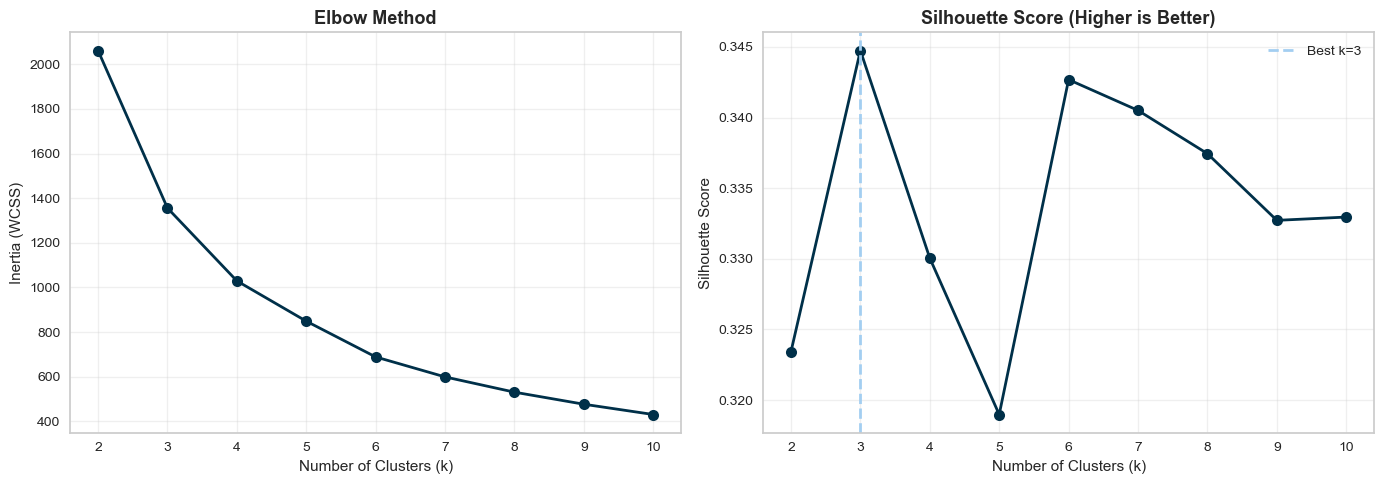


✓ Optimal k by Silhouette Score: 3



In [ ]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("\nTesting different values of k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))
    
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

# Plot metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'o-', color=C1, linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'o-', color=C1, linewidth=2, markersize=8)
best_k_sil = k_range[np.argmax(silhouette_scores)]
axes[1].axvline(best_k_sil, color=C2, linestyle='--', linewidth=2, label=f'Best k={best_k_sil}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Use the best k from silhouette score
optimal_k = best_k_sil

print(f"\n✓ Optimal k by Silhouette Score: {optimal_k}")
print()



K-MEANS CLUSTERING WITH OPTIMAL K


K-Means Performance:
  Silhouette Score: 0.3447
  Inertia: 1355.69



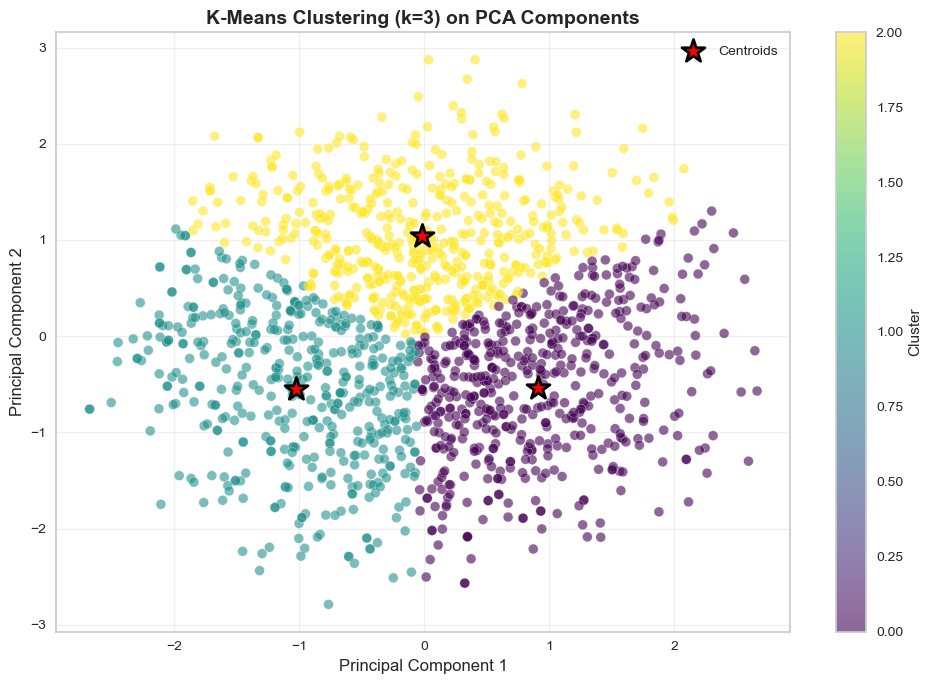

In [ ]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)

# Add to original data
data['KMeans_Cluster'] = kmeans_labels

# Evaluation metrics
sil_kmeans = silhouette_score(X_pca, kmeans_labels)

print(f"\nK-Means Performance:")
print(f"  Silhouette Score: {sil_kmeans:.4f}")
print(f"  Inertia: {kmeans_final.inertia_:.2f}")
print()

# Visualize K-Means clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                     cmap='viridis', alpha=0.6, edgecolors='w', s=50)
plt.scatter(kmeans_final.cluster_centers_[:, 0], 
           kmeans_final.cluster_centers_[:, 1],
           s=300, c='red', marker='*', edgecolors='black', linewidths=2,
           label='Centroids')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title(f'K-Means Clustering (k={optimal_k}) on PCA Components', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


K-MEANS CLUSTER PROFILING

In [ ]:
cluster_profile_kmeans = data.groupby('KMeans_Cluster')[cluster_features].mean().round(2)
cluster_counts_kmeans = data['KMeans_Cluster'].value_counts().sort_index()

print(f"\nCluster Sizes:")
print(cluster_counts_kmeans)
print(f"\nCluster Profiles:")
print(cluster_profile_kmeans)
print()


Cluster Sizes:
KMeans_Cluster
0    526
1    458
2    516
Name: count, dtype: int64

Cluster Profiles:
                  Age  AnnualIncome  NumberOfPurchases  TimeSpentOnWebsite  \
KMeans_Cluster                                                               
0               31.61      74034.57              13.44               24.82   
1               49.62      78631.93               5.27               25.44   
2               52.52      99647.55              11.91               40.69   

                DiscountsAvailed  
KMeans_Cluster                    
0                           2.70  
1                           1.52  
2                           3.33  



HIERARCHICAL CLUSTERING

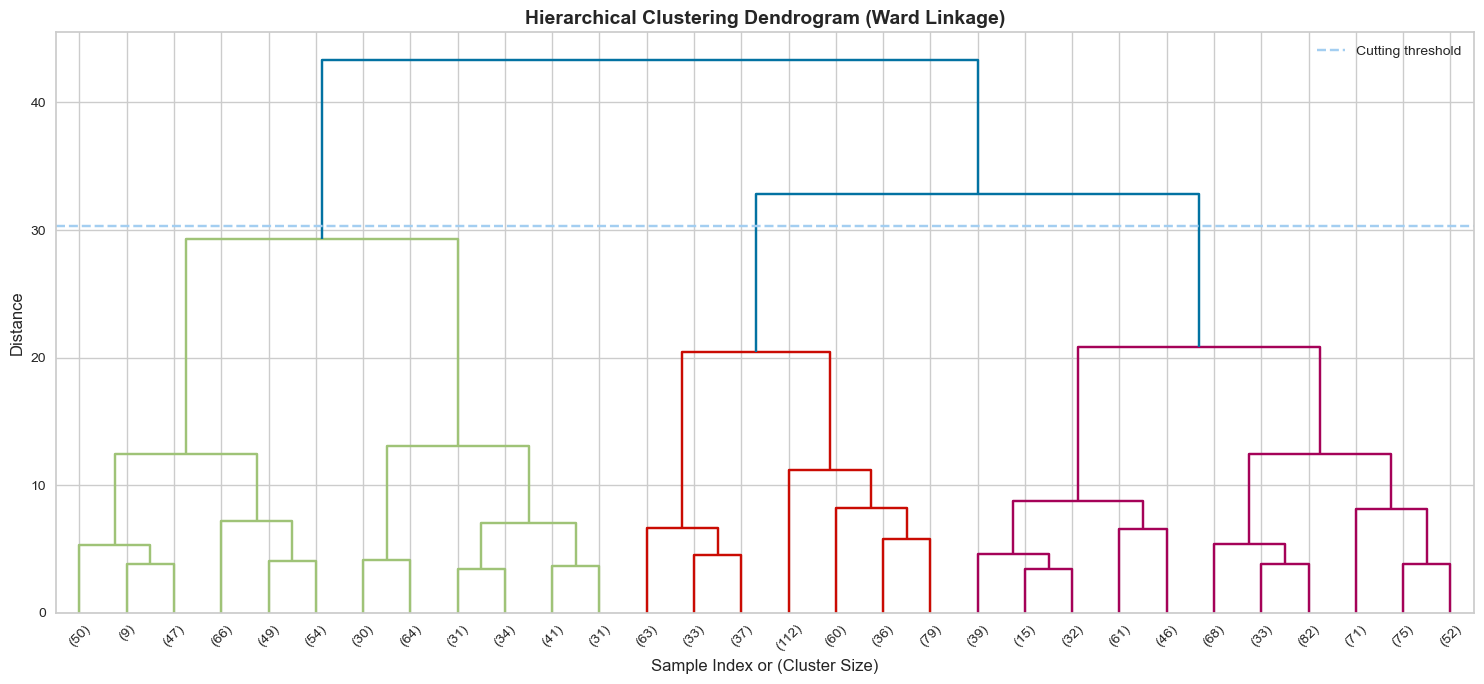

In [ ]:
# Create linkage matrix
linkage_matrix = linkage(X_pca, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, 
          truncate_mode='lastp',
          p=30,
          leaf_font_size=10,
          color_threshold=0.7*max(linkage_matrix[:,2]))
plt.xlabel('Sample Index or (Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.axhline(y=0.7*max(linkage_matrix[:,2]), color=C2, linestyle='--', label='Cutting threshold')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Fit hierarchical clustering with same k
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_pca)

# Add to data
data['Hierarchical_Cluster'] = hierarchical_labels

# Evaluation
sil_hierarchical = silhouette_score(X_pca, hierarchical_labels)

print(f"\nHierarchical Clustering Performance (k={optimal_k}):")
print(f"  Silhouette Score: {sil_hierarchical:.4f}")
print()


Hierarchical Clustering Performance (k=3):
  Silhouette Score: 0.2614



VISUALISATION OF CLUSTERS

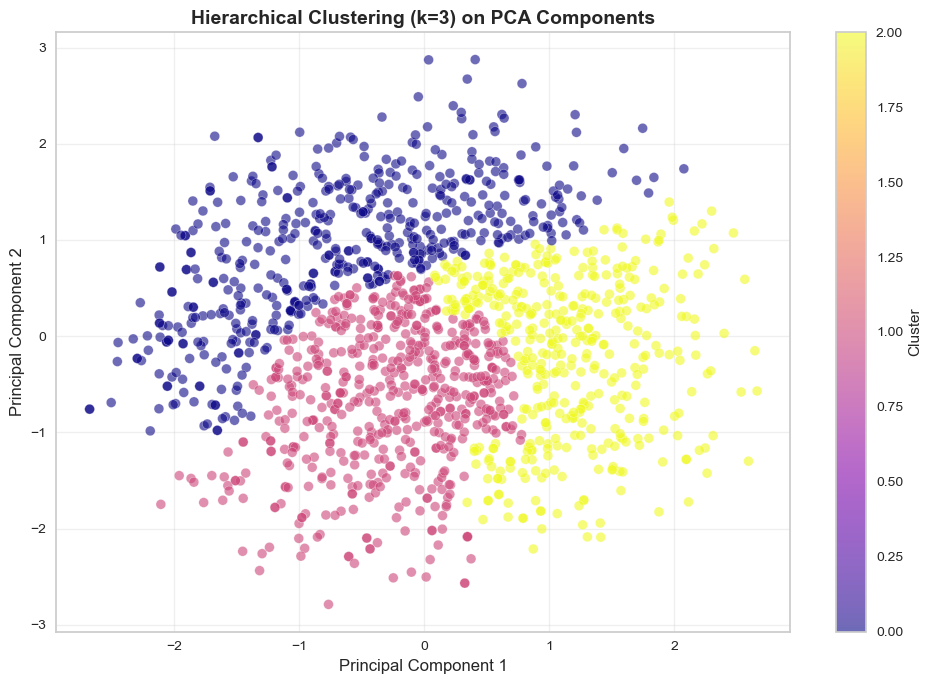

In [ ]:
# Visualize Hierarchical clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, 
                     cmap='plasma', alpha=0.6, edgecolors='w', s=50)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title(f'Hierarchical Clustering (k={optimal_k}) on PCA Components', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
cluster_profile_hierarchical = data.groupby('Hierarchical_Cluster')[cluster_features].mean().round(2)
cluster_counts_hierarchical = data['Hierarchical_Cluster'].value_counts().sort_index()

print(f"\nCluster Sizes:")
print(cluster_counts_hierarchical)
print(f"\nCluster Profiles:")
print(cluster_profile_hierarchical)
print()



Cluster Sizes:
Hierarchical_Cluster
0    506
1    574
2    420
Name: count, dtype: int64

Cluster Profiles:
                        Age  AnnualIncome  NumberOfPurchases  \
Hierarchical_Cluster                                           
0                     57.13      98791.16               9.10   
1                     41.53      75342.62               8.14   
2                     32.63      78901.80              15.13   

                      TimeSpentOnWebsite  DiscountsAvailed  
Hierarchical_Cluster                                        
0                                  40.02              2.86  
1                                  24.04              1.93  
2                                  27.75              3.05  



OMPARISON OF CLUSTERING METHODS

In [ ]:
comparison_df = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical'],
    'Silhouette Score': [sil_kmeans, sil_hierarchical],
    'Optimal K': [optimal_k, optimal_k]
})

print("\n", comparison_df.to_string(index=False))
print()

if sil_kmeans > sil_hierarchical:
    print("✓ K-Means performs better (higher Silhouette Score)")
    best_method = 'KMeans_Cluster'
    best_profile = cluster_profile_kmeans
else:
    print("✓ Hierarchical performs better (higher Silhouette Score)")
    best_method = 'Hierarchical_Cluster'
    best_profile = cluster_profile_hierarchical

print("FINAL CLUSTER PROFILES (BEST METHOD)")
print(best_profile)


       Method  Silhouette Score  Optimal K
     K-Means          0.344748          3
Hierarchical          0.261374          3

✓ K-Means performs better (higher Silhouette Score)
FINAL CLUSTER PROFILES (BEST METHOD)
                  Age  AnnualIncome  NumberOfPurchases  TimeSpentOnWebsite  \
KMeans_Cluster                                                               
0               31.61      74034.57              13.44               24.82   
1               49.62      78631.93               5.27               25.44   
2               52.52      99647.55              11.91               40.69   

                DiscountsAvailed  
KMeans_Cluster                    
0                           2.70  
1                           1.52  
2                           3.33  


Cluster labelling

In [ ]:
# Define cluster names based on characteristics
cluster_names = {
    0: "Young High-Spenders",      # Young (31), high purchases (13.4), high discounts (2.7)
    1: "Mature Low-Engagers",      # Older (49), low purchases (5.3), low discounts (1.5)
    2: "Affluent Active Shoppers"  # Older (52), highest income (99k), high engagement (11.9), most time online (40.7)
}

# Create final table with names
final_table = best_profile.copy()
final_table.insert(0, 'Cluster_Name', final_table.index.map(cluster_names))
final_table.insert(1, 'Cluster_ID', final_table.index)
final_table['Count'] = data[best_method].value_counts().sort_index().values

print("\n", final_table.to_string(index=False))


print("CLUSTER INTERPRETATIONS")

for cluster_id, name in cluster_names.items():
    count = data[best_method].value_counts()[cluster_id]
    print(f"\n{name} (Cluster {cluster_id}, n={count}):")
    profile = best_profile.loc[cluster_id]
    print(f"  • Average Age: {profile['Age']:.0f} years")
    print(f"  • Average Income: ${profile['AnnualIncome']:,.0f}")
    print(f"  • Average Purchases: {profile['NumberOfPurchases']:.1f}")
    print(f"  • Time on Website: {profile['TimeSpentOnWebsite']:.1f} minutes")
    print(f"  • Discounts Used: {profile['DiscountsAvailed']:.1f}")



             Cluster_Name  Cluster_ID   Age  AnnualIncome  NumberOfPurchases  TimeSpentOnWebsite  DiscountsAvailed  Count
     Young High-Spenders           0 31.61      74034.57              13.44               24.82              2.70    526
     Mature Low-Engagers           1 49.62      78631.93               5.27               25.44              1.52    458
Affluent Active Shoppers           2 52.52      99647.55              11.91               40.69              3.33    516
CLUSTER INTERPRETATIONS

Young High-Spenders (Cluster 0, n=526):
  • Average Age: 32 years
  • Average Income: $74,035
  • Average Purchases: 13.4
  • Time on Website: 24.8 minutes
  • Discounts Used: 2.7

Mature Low-Engagers (Cluster 1, n=458):
  • Average Age: 50 years
  • Average Income: $78,632
  • Average Purchases: 5.3
  • Time on Website: 25.4 minutes
  • Discounts Used: 1.5

Affluent Active Shoppers (Cluster 2, n=516):
  • Average Age: 53 years
  • Average Income: $99,648
  • Average Purchases: 11.9
 